# B&W Photography Clustering Pipeline

Clusters a photo library by **visual style and aesthetic character** — lighting, grain, tonal range, and composition — rather than semantic subject matter.

## Embedding backends (set `EMBED_MODEL` in config)

| Model | Best for | Speed |
|---|---|---|
| `dinov2` *(default)* | Style / texture / composition | ~15 img/s — self-supervised ViT, no language bias |
| `qwen3` | Semantic subject grouping | ~0.3 img/s — VLM, groups by scene content |

Each model caches embeddings to its own DuckDB table — switching does not invalidate existing cache.

## Clustering
- **UMAP** → 15 dimensions (`n_neighbors=15`, `min_dist=0.0`, cosine metric)
- **HDBSCAN** (`min_cluster_size=n//10`, `min_samples=2`, `cluster_selection_method='leaf'`)

## Hardware
Apple M4 Pro · 24 GB Unified Memory

In [29]:
import os
import gc
import json
import warnings
import hashlib
from pathlib import Path
from collections import defaultdict

import torch
import duckdb
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFile
from tqdm.auto import tqdm
import umap
from sklearn.cluster import HDBSCAN
from transformers import AutoProcessor, AutoModel, AutoImageProcessor

# --- Configuration ---
LIMIT = "All"  # Set to "All" to process everything, or an integer (e.g., 30)
DATA_DIR = Path("./data/raw")
DB_PATH = Path("./outputs/photos.duckdb")
RESULTS_PATH = Path("./outputs/results_v2.json")

# Embedding model: "qwen3" (semantic, VLM) or "dinov2" (style/texture, self-supervised)
EMBED_MODEL = "dinov2"

# Optimize MPS memory allocation
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"
warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = True

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"[✓] Using device: {DEVICE}")
print(f"[✓] Embedding model: {EMBED_MODEL}")

RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
import colorsys


[✓] Using device: mps
[✓] Embedding model: dinov2


In [30]:
def get_file_hash(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        h.update(f.read(65536))
    return h.hexdigest()[:16]

def safe_to_rgb(image_path: Path) -> Image.Image:
    img = Image.open(image_path)
    if img.mode in ("RGBA", "LA", "PA"):
        background = Image.new("RGB", img.size, (255, 255, 255))
        if img.mode == "PA":
            img = img.convert("RGBA")
        background.paste(img, mask=img.split()[-1])
        return background
    elif img.mode in ("L", "1", "P", "CMYK", "YCbCr"):
        return img.convert("RGB")
    return img.convert("RGB")

def discover_images(directory: Path):
    valid_exts = {".jpg", ".jpeg", ".png", ".tiff", ".webp"}
    images = []
    for f in directory.rglob("*"):
        if f.suffix.lower() in valid_exts and f.is_file():
            images.append(f)
    return sorted(images)

images_paths = discover_images(DATA_DIR)
if isinstance(LIMIT, int):
    print(f"[i] Applying limit: first {LIMIT} images.")
    images_paths = images_paths[:LIMIT]

print(f"[✓] Final count: {len(images_paths)} images to process.")

def _color_hex(cid: int) -> str:
    if cid == -1:
        return "#888888"
    n_real = len([l for l in labels if l != -1])
    h = (cid / max(n_real, 1)) % 1.0
    r, g, b = colorsys.hsv_to_rgb(h, 0.72, 0.92)
    return f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}"


[✓] Final count: 100 images to process.


In [31]:
# Release any connection left open by a previous interrupted run
try:
    con.close()
except Exception:
    pass

embeddings = []
valid_paths = []

MODELS_DIR = Path("./models")

if EMBED_MODEL == "dinov2":
    model_id = str(MODELS_DIR / "dinov2-large")
    db_table = "style_dinov2"
    print(f"[i] Stage 1: Loading {model_id}...")

    con = duckdb.connect(str(DB_PATH))
    con.execute(f"""
        CREATE TABLE IF NOT EXISTS {db_table} (
            photo_id   VARCHAR PRIMARY KEY,
            image_path VARCHAR NOT NULL,
            embedding  FLOAT[] NOT NULL,
            created_at TIMESTAMP DEFAULT now()
        )
    """)

    image_processor = AutoImageProcessor.from_pretrained(model_id)
    embed_model = AutoModel.from_pretrained(model_id, device_map="mps")
    embed_model.eval()

    print("[i] Processing images...")
    try:
        for path in tqdm(images_paths, desc="Stage 1 (DINOv2)"):
            pid = get_file_hash(path)
            existing = con.execute(f"SELECT embedding FROM {db_table} WHERE photo_id = ?", [pid]).fetchone()
            if existing:
                embeddings.append(np.array(existing[0]))
                valid_paths.append(path)
                continue
            try:
                img_rgb = safe_to_rgb(path)
                inputs = image_processor(images=img_rgb, return_tensors="pt").to(DEVICE)
                with torch.inference_mode():
                    outputs = embed_model(**inputs)
                # CLS token carries global style/texture summary
                emb = outputs.last_hidden_state[:, 0, :].detach().cpu().to(torch.float32).numpy().flatten()
                emb = emb / (np.linalg.norm(emb) + 1e-8)
                con.execute(f"INSERT INTO {db_table} (photo_id, image_path, embedding) VALUES (?, ?, ?)",
                            [pid, str(path.resolve()), emb.tolist()])
                embeddings.append(emb)
                valid_paths.append(path)
            except Exception as e:
                print(f"[!] Error processing {path.name}: {e}")
    finally:
        con.close()

elif EMBED_MODEL == "qwen3":
    model_id = str(MODELS_DIR / "Qwen3-VL-Embedding-2B")
    db_table = "style_qwen3"
    print(f"[i] Stage 1: Loading {model_id}...")

    con = duckdb.connect(str(DB_PATH))
    con.execute(f"""
        CREATE TABLE IF NOT EXISTS {db_table} (
            photo_id   VARCHAR PRIMARY KEY,
            image_path VARCHAR NOT NULL,
            embedding  FLOAT[] NOT NULL,
            created_at TIMESTAMP DEFAULT now()
        )
    """)

    processor = AutoProcessor.from_pretrained(model_id)
    embed_model = AutoModel.from_pretrained(
        model_id, dtype=torch.float16, attn_implementation="sdpa", device_map="mps"
    )
    embed_model.eval()

    print("[i] Processing images...")
    try:
        for path in tqdm(images_paths, desc="Stage 1 (Qwen3)"):
            pid = get_file_hash(path)
            existing = con.execute(f"SELECT embedding FROM {db_table} WHERE photo_id = ?", [pid]).fetchone()
            if existing:
                embeddings.append(np.array(existing[0]))
                valid_paths.append(path)
                continue
            try:
                img_rgb = safe_to_rgb(path)
                messages = [{"role": "user", "content": [{"type": "image", "image": img_rgb}, {"type": "text", "text": ""}]}]
                text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
                inputs = processor(text=[text], images=[img_rgb], return_tensors="pt", padding=True).to(DEVICE)
                with torch.inference_mode():
                    outputs = embed_model(**inputs)
                emb = outputs.last_hidden_state[:, -1, :].detach().cpu().to(torch.float32).numpy().flatten()
                emb = emb / (np.linalg.norm(emb) + 1e-8)
                con.execute(f"INSERT INTO {db_table} (photo_id, image_path, embedding) VALUES (?, ?, ?)",
                            [pid, str(path.resolve()), emb.tolist()])
                embeddings.append(emb)
                valid_paths.append(path)
            except Exception as e:
                print(f"[!] Error processing {path.name}: {e}")
    finally:
        con.close()

else:
    raise ValueError(f"Unknown EMBED_MODEL: '{EMBED_MODEL}'. Choose 'qwen3' or 'dinov2'.")

del embed_model
torch.mps.empty_cache()
gc.collect()

embeddings = np.array(embeddings)
print(f"[✓] Loaded {len(embeddings)} embeddings from {model_id}.")

[i] Stage 1: Loading models/dinov2-large...


Loading weights: 100%|██████████| 439/439 [00:00<00:00, 489.40it/s]


[i] Processing images...


Stage 1 (DINOv2): 100%|██████████| 100/100 [00:00<00:00, 2132.65it/s]


[✓] Loaded 100 embeddings from models/dinov2-large.


In [ ]:
print("[i] Clustering: UMAP -> HDBSCAN...")
if len(embeddings) > 5:
    # Lower n_components (15 vs 50) gives HDBSCAN clearer density structure
    n_comp = min(15, len(embeddings) - 2)
    n_comp = max(2, n_comp)
    init_method = 'spectral' if len(embeddings) > 40 else 'random'
    # n_neighbors=15 captures ~15% of 100-pt dataset for a more stable global structure
    n_neigh = min(15, len(embeddings) - 1)

    reducer = umap.UMAP(
        n_components=n_comp,
        n_neighbors=n_neigh,
        min_dist=0.0,
        init=init_method,
        metric='cosine',
        random_state=42
    )
    reduced_embs = reducer.fit_transform(embeddings)

    # Compute 2D projection now so the viz cell never needs to re-run UMAP
    vis_reducer = umap.UMAP(n_components=2, n_neighbors=n_neigh, min_dist=0.0, metric='cosine', random_state=42)
    vis_2d = vis_reducer.fit_transform(embeddings)

    # 'leaf' cuts the condensed tree at leaf level for granular groups.
    # min_cluster_size=n//10 enforces coherent groups (≈10 photos minimum).
    # min_samples=2 requires mutual density, eliminating orphan stray assignments.
    m_size = max(5, len(embeddings) // 10)
    clusterer = HDBSCAN(min_cluster_size=m_size, min_samples=2, cluster_selection_method='leaf', metric='euclidean')
    labels = clusterer.fit_predict(reduced_embs)
else:
    print("[!] Not enough samples for meaningful clustering. Assigning all to cluster 0.")
    labels = np.zeros(len(embeddings), dtype=int)
    vis_2d = np.zeros((len(embeddings), 2))

clusters = defaultdict(list)
for path, label in zip(valid_paths, labels):
    clusters[int(label)].append(path)

n_real = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"[✓] Found {n_real} clusters, {n_noise} noise points.")

[i] Generating Visualizations...


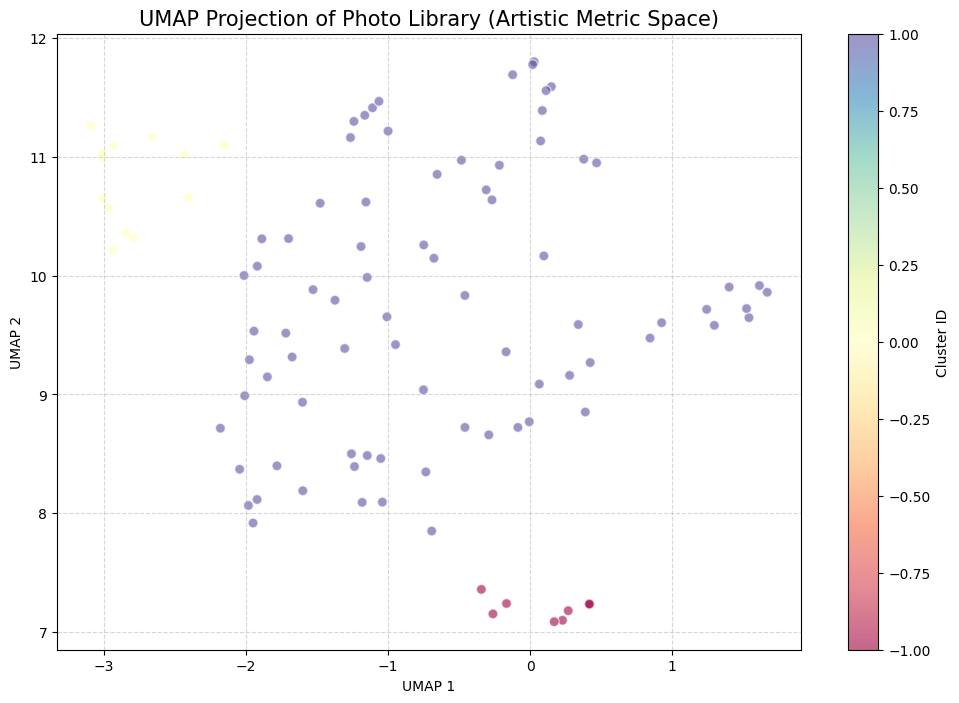


  NOISE (OUTLIERS) | 8 Images


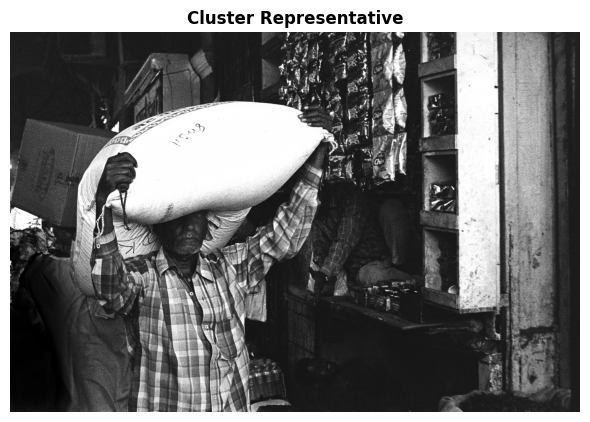

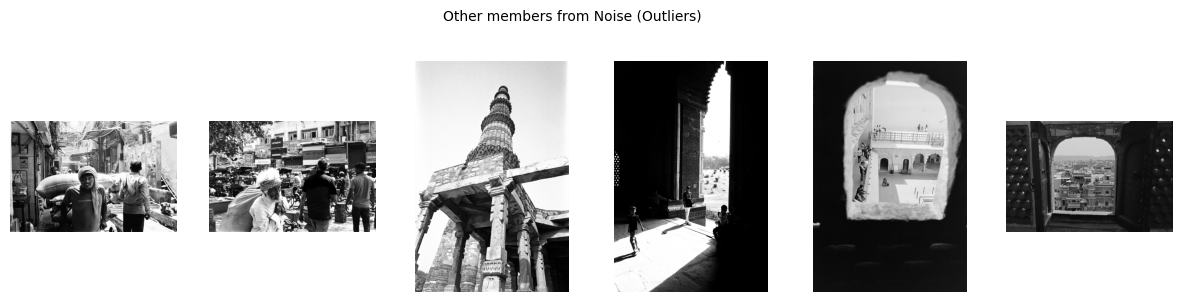


  CLUSTER 0 | 13 Images


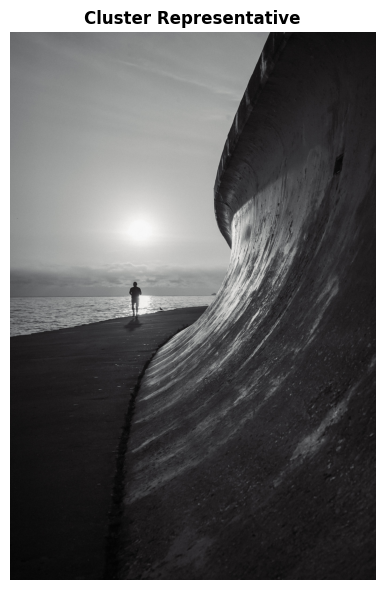

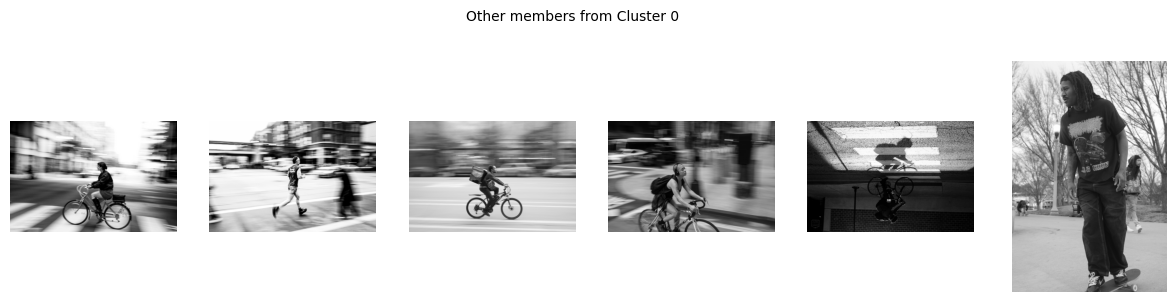


  CLUSTER 1 | 79 Images


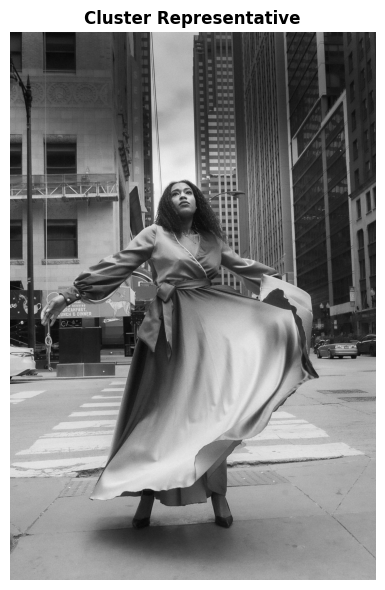

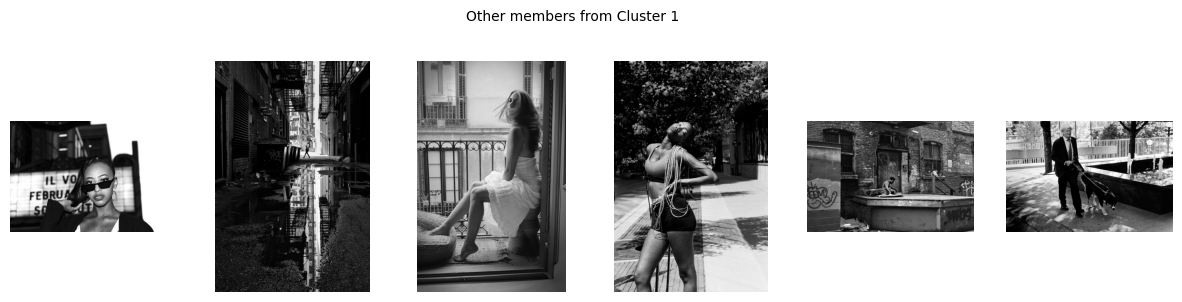

In [115]:
print("[i] Generating Visualizations...")

# --- 1. UMAP Manifold Visualization ---
if 'vis_2d' in locals() and len(vis_2d) > 0:
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(vis_2d[:, 0], vis_2d[:, 1], c=labels, cmap='Spectral', s=50, alpha=0.6, edgecolors='w')
    plt.colorbar(scatter, label='Cluster ID')
    plt.title("UMAP Projection of Photo Library (Artistic Metric Space)", fontsize=15)
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- 2. Cluster Gallery ---
cluster_results = [
    {
        "cluster_id": cid,
        "representative_path": str(clusters[cid][0]),
        "member_count": len(clusters[cid]),
        "sample_images": [str(p) for p in clusters[cid]],
    }
    for cid in sorted(clusters.keys())
]

for res in cluster_results:
    cluster_id = res["cluster_id"]
    name = "Noise (Outliers)" if cluster_id == -1 else f"Cluster {cluster_id}"
    member_paths = res["sample_images"]

    print(f"\n{'='*80}")
    print(f"  {name.upper()} | {res['member_count']} Images")
    print(f"{'='*80}")

    fig, ax_main = plt.subplots(1, 1, figsize=(6, 6))
    main_img = Image.open(res["representative_path"]).convert("RGB")
    ax_main.imshow(main_img)
    ax_main.set_title("Cluster Representative", fontsize=12, fontweight='bold')
    ax_main.axis("off")
    plt.tight_layout()
    plt.show()

    other_members = [p for p in member_paths if p != res["representative_path"]]
    if other_members:
        samples_to_show = min(6, len(other_members))
        fig, axes = plt.subplots(1, samples_to_show, figsize=(15, 3))
        if samples_to_show == 1: axes = [axes]

        for i in range(samples_to_show):
            s_img = Image.open(other_members[i]).convert("RGB")
            axes[i].imshow(s_img)
            axes[i].axis("off")

        plt.suptitle(f"Other members from {name}", fontsize=10, y=1.05)
        plt.show()

In [116]:
import base64
import io
import json as _json
import colorsys

HTML_OUT = Path("./outputs/html/clusters_interactive.html")
HTML_OUT.parent.mkdir(parents=True, exist_ok=True)

THUMB_SIZE = 220

print("[i] Encoding thumbnails as base64...")

def _thumb_b64(path: Path, size: int = THUMB_SIZE) -> str:
    img = Image.open(path).convert("RGB")
    img.thumbnail((size, size))
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=80)
    return "data:image/jpeg;base64," + base64.b64encode(buf.getvalue()).decode()


W, H, PAD = 900, 560, 44
x_min, x_max = float(vis_2d[:, 0].min()), float(vis_2d[:, 0].max())
y_min, y_max = float(vis_2d[:, 1].min()), float(vis_2d[:, 1].max())

def _to_px(x, y):
    px = PAD + (x - x_min) / (x_max - x_min + 1e-8) * (W - 2 * PAD)
    py = PAD + (1 - (y - y_min) / (y_max - y_min + 1e-8)) * (H - 2 * PAD)
    return round(px, 1), round(py, 1)

cluster_imgs: dict[str, list[str]] = {}
cluster_idx_ctr: dict[str, int] = {}
point_meta = []

for (x, y), label, path in zip(vis_2d, labels, valid_paths):
    key = str(int(label))
    t = _thumb_b64(path)
    cluster_imgs.setdefault(key, []).append(t)
    idx = cluster_idx_ctr.get(key, 0)
    cluster_idx_ctr[key] = idx + 1
    px, py = _to_px(float(x), float(y))
    color = _color_hex(int(label))
    name = Path(path).name.replace('"', '').replace("'", '')
    point_meta.append((key, idx, px, py, color, name))

print(f"    {len(point_meta)} photos · {len(cluster_imgs)} clusters")

# Scatter dots: inline CSS custom property --cc carries cluster color;
# src is set by JS after page load to avoid doubling base64 in HTML
img_tags = [
    f'<img data-c="{key}" data-i="{idx}" '
    f'style="left:{px}px;top:{py}px;--cc:{color}" '
    f'data-cluster="{key}" title="{name}">'
    for key, idx, px, py, color, name in point_meta
]

legend_items = []
for key in sorted(cluster_imgs.keys(), key=lambda k: int(k)):
    cid = int(key)
    color = _color_hex(cid)
    label_name = "Noise" if cid == -1 else f"Cluster {cid}"
    count = len(cluster_imgs[key])
    legend_items.append(
        f'<div class="li" data-cluster="{key}" style="border-left-color:{color}">'
        f'<span class="ln">{label_name}</span>'
        f'<span class="lc">{count}</span></div>'
    )

cluster_images_json = _json.dumps(cluster_imgs)
photos_html  = "\n".join(img_tags)
legend_html  = "\n".join(legend_items)

css = """
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body { background: #111; color: #eee; font-family: system-ui, sans-serif; }
  header { text-align: center; padding: 18px 0 6px; font-size: 1.2rem; font-weight: 600; color: #bbb; letter-spacing: .03em; }
  #hint { text-align: center; font-size: .78rem; color: #555; margin-bottom: 10px; }

  #explorer {
    display: flex; align-items: flex-start; gap: 14px;
    max-width: 1080px; margin: 0 auto; padding: 0 16px;
  }

  /* left column: scatter on top, cluster panel directly below */
  #left-col { display: flex; flex-direction: column; gap: 16px; flex-shrink: 0; }

  #scatter-wrap {
    position: relative; width: 900px; height: 560px;
    background: #1a1a1a; border-radius: 8px; overflow: hidden;
    cursor: grab; border: 1px solid #2a2a2a; user-select: none;
  }
  #scatter-inner { position: absolute; inset: 0; transform-origin: 0 0; }

  /* Default: small solid circle using cluster color */
  #scatter-inner img {
    position: absolute;
    width: 14px; height: 14px;
    border-radius: 50%;
    border: 2px solid var(--cc, #888);
    background-color: var(--cc, #888);
    object-fit: cover;
    transform: translate(-50%, -50%);
    cursor: pointer;
    transition: width .18s ease, height .18s ease, border-radius .18s ease, background-color .18s ease;
    z-index: 1;
  }
  /* Hover: expand to show the actual photo */
  #scatter-inner img:hover {
    width: 120px; height: 120px;
    border-radius: 8px;
    background-color: transparent;
    z-index: 100;
  }

  #legend { min-width: 136px; display: flex; flex-direction: column; gap: 5px; padding-top: 2px; }
  .li {
    display: flex; justify-content: space-between; align-items: center;
    padding: 5px 10px; border-left: 4px solid #555;
    background: #1c1c1c; border-radius: 0 5px 5px 0;
    cursor: pointer; transition: background .1s; font-size: .8rem;
  }
  .li:hover { background: #272727; }
  .ln { color: #ccc; }
  .lc { color: #555; font-size: .72rem; margin-left: 8px; }

  /* Cluster panel sits inside left-col, naturally left-aligned with scatter */
  #cluster-panel {
    display: none;
    width: 900px;
    background: #1c1c1c; border-radius: 10px; border: 1px solid #2e2e2e;
    padding: 18px 20px;
  }
  #cluster-title { font-size: 1rem; font-weight: 600; margin-bottom: 14px; color: #99ccff; }
  #photo-grid { display: grid; grid-template-columns: repeat(auto-fill, minmax(148px, 1fr)); gap: 8px; }
  #photo-grid img {
    width: 100%; border-radius: 6px; border: 1px solid #2a2a2a;
    object-fit: cover; aspect-ratio: 1; cursor: zoom-in;
    transition: transform .12s, border-color .12s;
  }
  #photo-grid img:hover { transform: scale(1.05); border-color: #555; }

  #lightbox { display: none; position: fixed; inset: 0; background: rgba(0,0,0,.9);
               justify-content: center; align-items: center; z-index: 999; }
  #lightbox.open { display: flex; }
  #lightbox img { max-width: 92vw; max-height: 92vh; border-radius: 6px; }
  #lb-close { position: fixed; top: 16px; right: 22px; font-size: 2rem;
               cursor: pointer; color: #aaa; user-select: none; }
  #lb-close:hover { color: #fff; }
"""

js = """
const clusterImages = """ + cluster_images_json + """;

document.querySelectorAll('#scatter-inner img[data-c]').forEach(img => {
  img.src = clusterImages[img.dataset.c][parseInt(img.dataset.i)];
});

const wrap  = document.getElementById('scatter-wrap');
const inner = document.getElementById('scatter-inner');
const panel = document.getElementById('cluster-panel');
const title = document.getElementById('cluster-title');
const grid  = document.getElementById('photo-grid');
const lb    = document.getElementById('lightbox');
const lbImg = document.getElementById('lb-img');

function showCluster(cid) {
  const key  = String(cid);
  const imgs = clusterImages[key] || [];
  const name = key === '-1' ? 'Noise / Outliers' : 'Cluster ' + key;
  title.textContent = name + '  —  ' + imgs.length + ' photo' + (imgs.length !== 1 ? 's' : '');
  grid.innerHTML = '';
  imgs.forEach(src => {
    const img = document.createElement('img');
    img.src = src;
    img.addEventListener('click', () => { lbImg.src = src; lb.classList.add('open'); });
    grid.appendChild(img);
  });
  panel.style.display = 'block';
  panel.scrollIntoView({ behavior: 'smooth', block: 'nearest' });
}

document.querySelectorAll('#scatter-inner img').forEach(img => {
  img.addEventListener('click', e => { e.stopPropagation(); showCluster(img.dataset.cluster); });
});
document.querySelectorAll('.li').forEach(item => {
  item.addEventListener('click', () => showCluster(item.dataset.cluster));
});

// Zoom (wheel, centered on cursor)
let scale = 1, tx = 0, ty = 0;
wrap.addEventListener('wheel', e => {
  e.preventDefault();
  const rect = wrap.getBoundingClientRect();
  const mx = e.clientX - rect.left, my = e.clientY - rect.top;
  const ns = Math.max(0.35, Math.min(6, scale * (e.deltaY < 0 ? 1.12 : 0.89)));
  tx = mx - (mx - tx) * (ns / scale);
  ty = my - (my - ty) * (ns / scale);
  scale = ns;
  inner.style.transform = 'translate(' + tx + 'px,' + ty + 'px) scale(' + scale + ')';
}, { passive: false });

// Pan (drag)
let dragging = false, ox = 0, oy = 0;
wrap.addEventListener('mousedown', e => {
  dragging = true; ox = e.clientX - tx; oy = e.clientY - ty;
  wrap.style.cursor = 'grabbing';
});
document.addEventListener('mousemove', e => {
  if (!dragging) return;
  tx = e.clientX - ox; ty = e.clientY - oy;
  inner.style.transform = 'translate(' + tx + 'px,' + ty + 'px) scale(' + scale + ')';
});
document.addEventListener('mouseup', () => { dragging = false; wrap.style.cursor = 'grab'; });

document.getElementById('lb-close').addEventListener('click', () => lb.classList.remove('open'));
lb.addEventListener('click', e => { if (e.target === lb) lb.classList.remove('open'); });
document.addEventListener('keydown', e => { if (e.key === 'Escape') lb.classList.remove('open'); });
"""

html = (
    "<!DOCTYPE html>\n<html lang=\"en\">\n<head>\n"
    "<meta charset=\"UTF-8\">\n<title>Photo Cluster Explorer</title>\n"
    "<style>" + css + "</style>\n</head>\n<body>\n"
    "<header>Photo Cluster Explorer &middot; DINOv2</header>\n"
    "<div id=\"hint\">Scroll to zoom &middot; Drag to pan &middot; Hover to preview &middot; Click to see cluster</div>\n"
    "<div id=\"explorer\">\n"
    "  <div id=\"left-col\">\n"
    "    <div id=\"scatter-wrap\"><div id=\"scatter-inner\">\n"
    + photos_html + "\n"
    "    </div></div>\n"
    "    <div id=\"cluster-panel\">\n"
    "      <div id=\"cluster-title\"></div>\n"
    "      <div id=\"photo-grid\"></div>\n"
    "    </div>\n"
    "  </div>\n"
    "  <div id=\"legend\">\n" + legend_html + "\n  </div>\n"
    "</div>\n"
    "<div id=\"lightbox\">\n"
    "  <span id=\"lb-close\">&#215;</span>\n"
    "  <img id=\"lb-img\" src=\"\" alt=\"\">\n"
    "</div>\n"
    "<script>" + js + "</script>\n"
    "</body>\n</html>"
)

HTML_OUT.write_text(html, encoding="utf-8")
sz_mb = HTML_OUT.stat().st_size / 1_048_576
print(f"[✓] Saved → {HTML_OUT}  ({sz_mb:.1f} MB)")
print(f"    Open with:  open {HTML_OUT}")

[i] Encoding thumbnails as base64...
    100 photos · 3 clusters
[✓] Saved → outputs/html/clusters_interactive.html  (1.0 MB)
    Open with:  open outputs/html/clusters_interactive.html


In [117]:
print("[i] Exporting Results...")
with open(RESULTS_PATH, "w", encoding="utf-8") as f:
    json.dump(cluster_results, f, indent=2)
print(f"[✓] Results saved to {RESULTS_PATH}")

[i] Exporting Results...
[✓] Results saved to outputs/results_v2.json


## Part 2: Text Search (Qwen3-VL-Embedding-2B)

Queries are encoded by the same Qwen3-VL model used for image embeddings — no extra models needed.
Results are shown as a gallery plus highlighted in the UMAP scatter.

Set `QUERY` and `TOP_N` below and run the cell.

Loading weights: 100%|██████████| 625/625 [00:04<00:00, 151.33it/s]


[✓] Query vector ready: 'solitary figure'


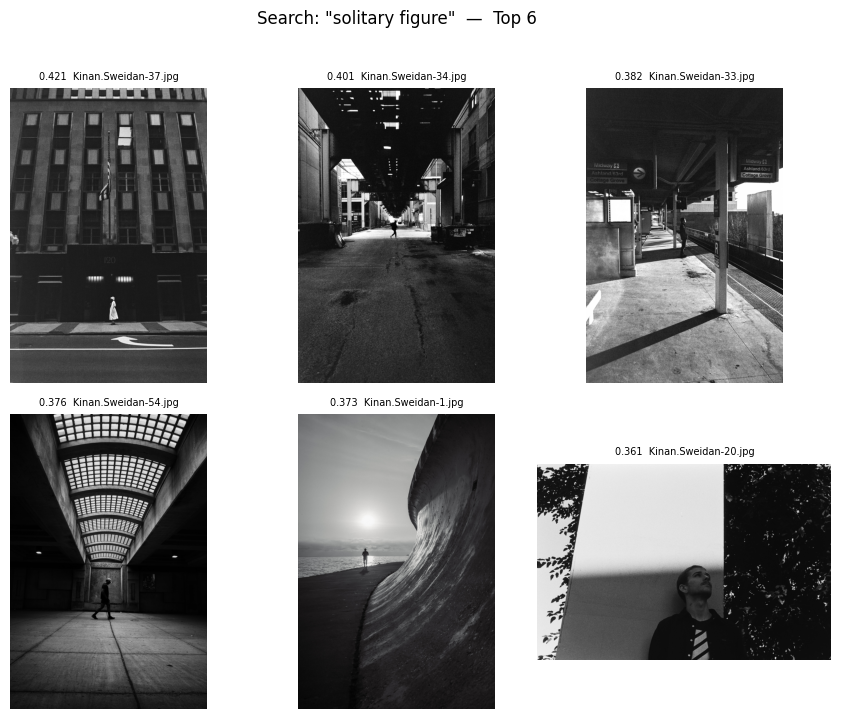

In [118]:
QUERY = "solitary figure"
TOP_N = 6

_qwen_id = str(Path("./models/Qwen3-VL-Embedding-2B"))
_proc  = AutoProcessor.from_pretrained(_qwen_id)
_model = AutoModel.from_pretrained(
    _qwen_id, dtype=torch.float16, attn_implementation="sdpa", device_map="mps"
)
_model.eval()

# Text-only message through the same chat template used for images
_messages = [{"role": "user", "content": [{"type": "text", "text": QUERY}]}]
_text = _proc.apply_chat_template(_messages, tokenize=False, add_generation_prompt=True)
_inputs = _proc(text=[_text], return_tensors="pt", padding=True).to(DEVICE)
with torch.inference_mode():
    _out = _model(**_inputs)
q_emb = _out.last_hidden_state[:, -1, :].detach().cpu().to(torch.float32).numpy().flatten()
q_emb /= (np.linalg.norm(q_emb) + 1e-8)

del _model; torch.mps.empty_cache(); gc.collect()
print(f"[✓] Query vector ready: '{QUERY}'")

# Score against style_qwen3 embeddings
con = duckdb.connect(str(DB_PATH))
rows = con.execute("SELECT photo_id, image_path, embedding FROM style_qwen3").fetchall()
con.close()

path_to_umap = {str(p.resolve()): (float(x), float(y))
                for p, (x, y) in zip(valid_paths, vis_2d)}

scored = []
for pid, img_path, emb in rows:
    sim = float(np.dot(q_emb, np.array(emb)))
    scored.append((sim, img_path, path_to_umap.get(img_path)))
scored.sort(reverse=True)
top_results = scored[:TOP_N]

# 2-row gallery
cols = (TOP_N + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 7))
for i, (score, img_path, _) in enumerate(top_results):
    ax = axes[i // cols][i % cols]
    ax.imshow(safe_to_rgb(Path(img_path)))
    ax.axis("off")
    ax.set_title(f"{score:.3f}  {Path(img_path).name}", fontsize=7)
for ax in axes.flatten()[len(top_results):]:
    ax.axis("off")
plt.suptitle(f'Search: "{QUERY}"  —  Top {TOP_N}', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


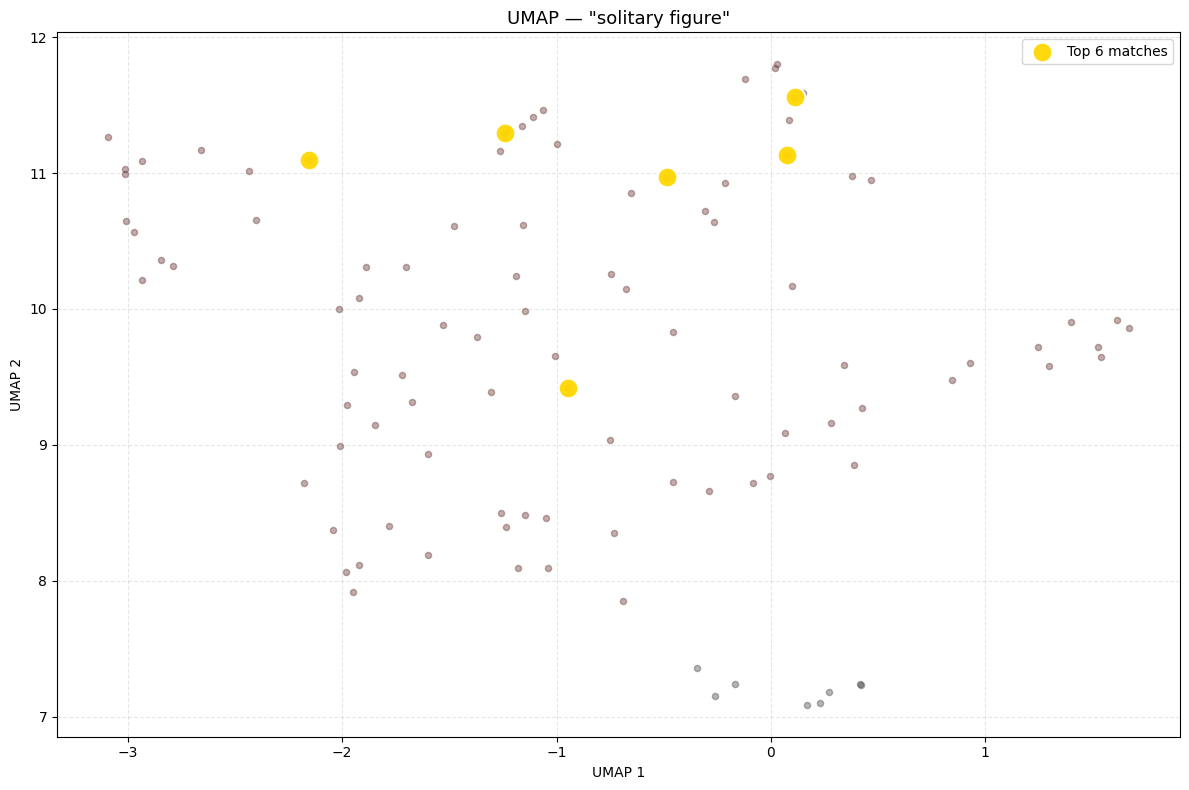

  [0.421] Kinan.Sweidan-37.jpg  —  Cluster 1
  [0.401] Kinan.Sweidan-34.jpg  —  Cluster 1
  [0.382] Kinan.Sweidan-33.jpg  —  Cluster 1
  [0.376] Kinan.Sweidan-54.jpg  —  Cluster 1
  [0.373] Kinan.Sweidan-1.jpg  —  Cluster 0
  [0.361] Kinan.Sweidan-20.jpg  —  Cluster 1


In [119]:
fig, ax = plt.subplots(figsize=(12, 8))
for cid in sorted(set(int(l) for l in labels)):
    mask = np.array([int(l) == cid for l in labels])
    ax.scatter(vis_2d[mask, 0], vis_2d[mask, 1],
               c=[_color_hex(cid)], s=18, alpha=0.2, zorder=1)
ax.scatter(vis_2d[:, 0], vis_2d[:, 1], c="#444", s=20, alpha=0.3, zorder=2)

hit_xy = [pos for _, _, pos in top_results if pos is not None]
if hit_xy:
    hx, hy = zip(*hit_xy)
    ax.scatter(hx, hy, c="#FFD700", s=200, alpha=0.95,
               edgecolors="#fff", linewidths=1.5, zorder=4, label=f"Top {TOP_N} matches")
ax.legend(fontsize=10)
ax.set_title(f'UMAP — "{QUERY}"', fontsize=13)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

for score, img_path, _ in top_results:
    idx = next((i for i, p in enumerate(valid_paths) if str(p.resolve()) == img_path), None)
    lbl = labels[idx] if idx is not None else -999
    cluster = "Noise" if lbl == -1 else f"Cluster {lbl}"
    print(f"  [{score:.3f}] {Path(img_path).name}  —  {cluster}")
